<a href="https://colab.research.google.com/github/priyansh-commits/practice/blob/main/regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge,Lasso
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

In [2]:
sc=StandardScaler()
df = load_diabetes()
al=np.array([0,1e-5,1e-4,1e-3,1e-2,1e-1,1])
X_train,X_test,y_train,y_test=train_test_split(df.data,df.target,test_size=0.2,random_state=2)
for i in al:
  r=Ridge(alpha=i)
  r.fit(X_train,y_train)
  print(r2_score(y_test,r.predict(X_test))*100,mean_squared_error(y_test,r.predict(X_test))**0.5)




43.99338661568966 55.62784079546917
43.99449697235377 55.62728936907372
44.004295115526745 55.62242316881659
44.08617113920028 55.58174318441026
44.39392894728016 55.428567137568024
45.199494197195456 55.02560551161431
40.78252224517157 57.20019371687056


/tmp/ipykernel_792/3037914351.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


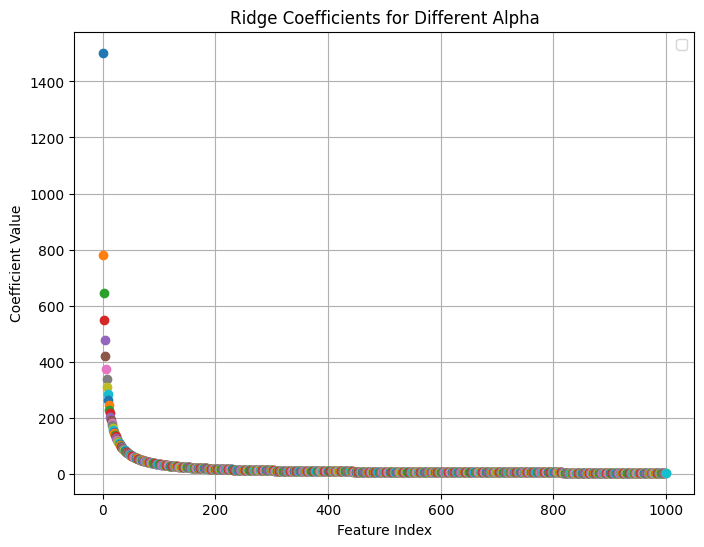

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
import numpy as np

df = load_diabetes()

X_train, X_test, y_train, y_test = train_test_split(
    df.data, df.target, test_size=0.2, random_state=2
)

alphas = np.linspace(0, 1000, 1000)

plt.figure(figsize=(8,6))

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    plt.plot(alpha,model.coef_.sum(), marker='o')

plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Ridge Coefficients for Different Alpha")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
class myridge:
  def __init__(self,al=0.01):
    self.alpha=al
  def fit(self,X,y):
    X=np.ravel(X)
    y=np.ravel(y)
    x_mean = X.mean()
    y_mean = y.mean()

    num = np.sum((X-x_mean)*(y-y_mean))
    den = np.sum((X-x_mean)**2) + self.alpha

    self.m = num/den
    self.b = y_mean - self.m*x_mean
    # self.b=y.mean()-self.m*X.mean()
    return (self.m,self.b)
  def pred(self,X_test):
    return np.ravel(X_test)*self.m+self.b
  def score(self,X_test,y_test):
    X_test=np.ravel(X_test)
    y_test=np.ravel(y_test)
    y_pred=self.pred(X_test)
    return 1-np.sum((y_test-y_pred)**2)/np.sum((y_test.mean()-y_test)**2)
rid=myridge()
import numpy as np

# Training data
X_train = np.array([
    [1],
    [2],
    [3],
    [4],
    [5],
    [6],
    [7],
    [8]
])

y_train = np.array([
    3,
    5,
    7,
    9,
    11,
    13,
    15,
    17
])

# Test data
X_test = np.array([
    [1.5],
    [2.5],
    [4.5],
    [6.5],
    [7.5]
])

y_test = np.array([
    4,
    6,
    10,
    14,
    16
])
# rid.fit(X_train,y_train)
# print(rid.score(X_test,y_test))
# print(rid.fit(X_train,y_train))
for i in np.linspace(0,10,100):
  rid=myridge(i)
  rid.fit(X_train,y_train)
  print(rid.score(X_test,y_test))

1.0
0.9999942436846313
0.9999770848280709
0.9999486867923909
0.9999092106066525
0.9998588150038312
0.999797656457086
0.9997258892153853
0.9996436653385035
0.999551134731399
0.9994484451779878
0.9993357423743224
0.9992131699611896
0.9990808695561372
0.998938980784942
0.9987876413125286
0.9986269868733509
0.998457151301246
0.9982782665587714
0.998090462766034
0.9978938682290233
0.9976886094674556
0.9974748112421403
0.9972525965818769
0.9970220868098919
0.9967834015698236
0.9965366588512651
0.9962819750148721
0.9960194648170446
0.9957492414341907
0.99547141648658
0.9951861000617943
0.9948934007377839
0.9945934256055363
0.9942862802913641
0.9939720689788203
0.9936508944302471
0.9933228580079662
0.9929880596951146
0.9926465981161368
0.9922985705569346
0.991944072984686
0.9915832000673345
0.9912160451927586
0.9908427004876262
0.9904632568359375
0.9900778038972661
0.9896864301247004
0.9892892227824925
0.9888862679634199
0.9884776506058636
0.98806345451061
0.98764376235738
0.9872186557210917
0

In [6]:
class myridge2:
  def __init__(self,al=0.01):
    self.alpha=al
    self.inter=None
    self.w=None
  def fit(self,X,y):
    X=np.insert(X,0,1,1)
    I=np.identity(X.shape[1])
    coef=np.linalg.inv(np.dot(X.T,X)+self.alpha*I)@(X.T@y)
    self.inter=coef[0]
    self.w=coef[1:]
    # self.b=y.mean()-self.m*X.mean()
    return self.inter,self.w
  def pred(self,X_test):
    return X_test@self.w+self.inter
  def score(self,X_test,y_test):

    y_pred=self.pred(X_test)
    return 1-np.sum((y_test-y_pred)**2)/np.sum((y_test.mean()-y_test)**2)
df = load_diabetes()

X_train, X_test, y_train, y_test = train_test_split(
    df.data, df.target, test_size=0.2, random_state=2
)
for i in np.linspace(0,1,100):
  rid=myridge2(i)
  rid.fit(X_train,y_train)
  lr=LinearRegression()
  lr.fit(X_train,y_train)
  # print(lr.coef_)
  # print(rid.fit(X_train,y_train))
  # print(lr.intercept_)
  print(i,"->",(r2_score(y_test,lr.predict(X_test))-r2_score(y_test,rid.pred(X_test))))


0.0 -> 4.440892098500626e-16
0.010101010101010102 -> -0.004021515311387613
0.020202020202020204 -> -0.005571299933416207
0.030303030303030304 -> -0.0068120503634814256
0.04040404040404041 -> -0.007889149120067773
0.05050505050505051 -> -0.00883727020864622
0.06060606060606061 -> -0.00967288216165274
0.07070707070707072 -> -0.010407105466161082
0.08080808080808081 -> -0.011048686348154702
0.09090909090909091 -> -0.01160498361424911
0.10101010101010102 -> -0.012082401023588707
0.11111111111111112 -> -0.012486619707263502
0.12121212121212122 -> -0.012822742141312404
0.13131313131313133 -> -0.013095390344168178
0.14141414141414144 -> -0.013308777454726695
0.15151515151515152 -> -0.013466762447113534
0.16161616161616163 -> -0.013572893458067115
0.17171717171717174 -> -0.013630443038049167
0.18181818181818182 -> -0.013642437447283329
0.19191919191919193 -> -0.013611681419600341
0.20202020202020204 -> -0.013540779385193269
0.21212121212121213 -> -0.013432153864878726
0.22222222222222224 -> -0

In [14]:
class myridge3:
  def __init__(self,al=0.01,ep=10000,lr=1e-4):
    self.alpha=al
    self.inter=None
    self.w=None
    self.lr=lr
    self.ep=ep
  def fit(self,X,y):
    X=np.insert(X,0,1,1)


    W=np.ones(X.shape[1])
    W[0]=0

    for i in range(self.ep):

      der = X.T @ X @ W - X.T @ y + self.alpha * W
      W-=self.lr*der
    self.inter=W[0]
    self.w=W[1:]

    return self.inter,self.w
  def pred(self,X_test):
    return X_test@self.w+self.inter
  def score(self,X_test,y_test):

    y_pred=self.pred(X_test)
    return 1-np.sum((y_test-y_pred)**2)/np.sum((y_test.mean()-y_test)**2)
df = load_diabetes()

X_train, X_test, y_train, y_test = train_test_split(
    df.data, df.target, test_size=0.2, random_state=2
)
for i in np.linspace(0,1,100):
  rid=myridge3(i)
  rid.fit(X_train,y_train)
  lr=LinearRegression()
  lr.fit(X_train,y_train)
  # print(lr.coef_)
  # print(rid.fit(X_train,y_train))
  # print(lr.intercept_)
  print(i,"->",(r2_score(y_test,lr.predict(X_test))-r2_score(y_test,rid.pred(X_test))))


0.0 -> 0.006183566581284938
0.010101010101010102 -> 0.006453506480447402
0.020202020202020204 -> 0.0067292087135452094
0.030303030303030304 -> 0.00701056849717463
0.04040404040404041 -> 0.007297482597762195
0.05050505050505051 -> 0.007589849309205254
0.06060606060606061 -> 0.007887568430839154
0.07070707070707072 -> 0.008190541245728822
0.08080808080808081 -> 0.00849867049927211
0.09090909090909091 -> 0.008811860378117875
0.10101010101010102 -> 0.009130016489391934
0.11111111111111112 -> 0.009453045840222218
0.12121212121212122 -> 0.009780856817567463
0.13131313131313133 -> 0.010113359168333225
0.14141414141414144 -> 0.010450463979781999
0.15151515151515152 -> 0.010792083660226881
0.16161616161616163 -> 0.011138131920006678
0.17171717171717174 -> 0.011488523752734903
0.18181818181818182 -> 0.011843175416825669
0.19191919191919193 -> 0.012202004417284695
0.20202020202020204 -> 0.012564929487765664
0.21212121212121213 -> 0.01293187057288725
0.22222222222222224 -> 0.01330274881080884
0.23

In [25]:
df = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    df.data, df.target, test_size=0.2, random_state=2
)
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=0.1)
lasso.fit(X_train,y_train)
for i in np.linspace(0,0.1,100):
  lasso=Lasso(alpha=i)
  lasso.fit(X_train,y_train)
  lr.fit(X_train,y_train)
  print(i,'lr-',r2_score(y_test,lr.predict(X_test))*100,' lasso-',r2_score(y_test,lasso.predict(X_test))*100)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.967e+05, tolerance: 2.124e+02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

0.0 lr- 43.99338661568968  lasso- 43.993386625818744
0.00101010101010101 lr- 43.99338661568968  lasso- 44.03043937281825
0.00202020202020202 lr- 43.99338661568968  lasso- 44.061505406482546
0.0030303030303030303 lr- 43.99338661568968  lasso- 44.08660125376146
0.00404040404040404 lr- 43.99338661568968  lasso- 44.10575160208927
0.00505050505050505 lr- 43.99338661568968  lasso- 44.11459266072549
0.006060606060606061 lr- 43.99338661568968  lasso- 44.113243182156005
0.007070707070707071 lr- 43.99338661568968  lasso- 44.11089133751428
0.00808080808080808 lr- 43.99338661568968  lasso- 44.10970063968425
0.00909090909090909 lr- 43.99338661568968  lasso- 44.11203293060603
0.0101010101010101 lr- 43.99338661568968  lasso- 44.1116935097419
0.011111111111111112 lr- 43.99338661568968  lasso- 44.10861598798109
0.012121212121212121 lr- 43.99338661568968  lasso- 44.10282768765153
0.013131313131313131 lr- 43.99338661568968  lasso- 44.094360219078546
0.014141414141414142 lr- 43.99338661568968  lasso- 44.0